In [20]:
import os
import sys

venv_path = os.path.abspath(r"..\granola.ai\Lib\site-packages")
if venv_path not in sys.path:
    sys.path.insert(0, venv_path)

In [21]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
sns.set_theme(style="darkgrid")

In [22]:
base_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
data_path = os.path.join(base_dir, "data", "dataset.csv")
df = pd.read_csv(data_path)

In [23]:
df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"], format="%Y-%m-%d")
df["First Response Time"] = pd.to_datetime(df["First Response Time"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df["Time to Resolution"] = pd.to_datetime(df["Time to Resolution"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

df_ticket = df.drop(columns=["Ticket ID"])
df_ticket["Resolution"] = df_ticket["Resolution"].fillna("None")
df_ticket["First Response Time"] = df_ticket["First Response Time"].fillna("No response")
df_ticket["Time to Resolution"] = df_ticket["Time to Resolution"].fillna("No resolution")
df_ticket["Customer Satisfaction Rating"] = df_ticket["Customer Satisfaction Rating"].fillna("No rating")

In [24]:
age = []
for i in df_ticket["Customer Age"]:
    if i <= 30:
        age.append("Young Customer")
    elif 30 < i < 55:
        age.append("Middle Age Customer")
    else:
        age.append("Old Customer")
df_ticket["Type of Customer"] = age

chance_r = []
for i in df_ticket["Time to Resolution"]:
    if i == "No resolution":
        chance_r.append("No")
    else:
        chance_r.append("Yes")
df_ticket["Resolution_bin"] = chance_r

In [25]:
df_resolution = df_ticket[df_ticket["Resolution_bin"] == "Yes"].copy()

rating = []
for i in df_resolution["Customer Satisfaction Rating"]:
    if isinstance(i, (int, float)) and i <= 2:
        rating.append("Low")
    elif isinstance(i, (int, float)) and i == 3:
        rating.append("Medium")
    else:
        rating.append("High")
df_resolution["Type of rating"] = rating

In [26]:
# Separate target and features (Target removed to prevent leakage)
y_raw = df_resolution["Type of rating"]
X_raw = df_resolution.drop(
    columns=[
        "Customer Name",
        "Customer Email",
        "Customer Age",
        "Product Purchased",
        "Date of Purchase",
        "Ticket Description",
        "Ticket Status",
        "First Response Time",
        "Time to Resolution",
        "Response",
        "Resolution_bin",
        "Resolution",
        "Customer Satisfaction Rating",
        "Type of rating",
    ],
    errors="ignore",
)

# Train-test split before encoding
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=0)

In [27]:
# Encode categorical features
feature_cols = X_train.columns
for col in feature_cols:
    encoder = LabelEncoder()
    X_train[col] = encoder.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).map(lambda s: '<unknown>' if s not in encoder.classes_ else s)
    encoder.classes_ = np.append(encoder.classes_, '<unknown>')
    X_test[col] = encoder.transform(X_test[col])

# Feature Scaling (Crucial for Logistic Regression solvers)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Encode target
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train_raw)
y_test = target_encoder.transform(y_test_raw)

In [28]:
# Hyperparameter grid
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'newton-cg'],
        'max_iter': [1000]
    },
    {
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000]
    }
]

# Running grid search with n_jobs=1 to avoid worker crash
grid_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('--- Hyperparameter Tuning Results ---')
print('Best Parameters:', grid_search.best_params_)
print('Best CV Score:', grid_search.best_score_)

# Fit and predict with best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
--- Hyperparameter Tuning Results ---
Best Parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.33282355127786034


              precision    recall  f1-score   support

           0       0.42      0.66      0.51       228
           1       0.39      0.36      0.37       224
           2       0.00      0.00      0.00       112

    accuracy                           0.41       564
   macro avg       0.27      0.34      0.30       564
weighted avg       0.32      0.41      0.36       564



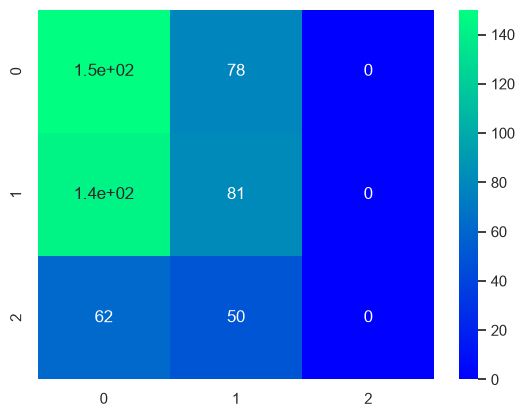

In [29]:
print(classification_report(y_test, y_pred))

matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, cmap="winter", annot=True)
plt.show()